In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos de prueba....
- Vamos a cargar datos de prueba a nivel operativo, sólo para entender como operacionalizamos, luego, profundizar y entender más....
- Los datos que usaremos son de UCI de un dataset super conocido y estándar..... **Clasificación de vinos....** (https://archive.ics.uci.edu/dataset/186/wine+quality)

In [2]:
!pip3 install ucimlrepo --break-system-packages

In [3]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
# metadata 
print(wine_quality.metadata) 
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [4]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [5]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


In [6]:
X.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


In [7]:
## Split del conjunto de datos...
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=137)

In [8]:
## Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
## Decision Trees: https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html#sphx-glr-auto-examples-tree-plot-tree-regression-py
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [9]:
dt = DecisionTreeRegressor(random_state=0)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [10]:
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

/opt/homebrew/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=0)

In [11]:
### Analicemos algunas métricas....
from sklearn.metrics import accuracy_score, mean_absolute_percentage_error, mean_squared_error, r2_score, precision_score

In [12]:
y_pred_test_dt=dt.predict(X_test)
y_pred_test_rf=rf.predict(X_test)
# ....

In [13]:
### Para Decision Tree:
print("Predicción a nivel de Test dataset... (Decision Tree)")
for i,j in zip(["MSE","MAPE","R2-score"],[mean_squared_error,mean_absolute_percentage_error,r2_score]):
    print("Metric = {} = {}".format(i,j(y_test,y_pred_test_dt)))

Predicción a nivel de Test dataset... (Decision Tree)
Metric = MSE = 0.772960372960373
Metric = MAPE = 0.09692529692529693
Metric = R2-score = -0.010730239460885027


In [14]:
### Para Random Forest:
print("Predicción a nivel de Test dataset... (Random Forest)")
for i,j in zip(["MSE","MAPE","R2-score"],[mean_squared_error,mean_absolute_percentage_error,r2_score]):
    print("Metric = {} = {}".format(i,j(y_test,y_pred_test_rf)))

Predicción a nivel de Test dataset... (Random Forest)
Metric = MSE = 0.3783745454545454
Metric = MAPE = 0.08192557442557441
Metric = R2-score = 0.5052338925623263


In [15]:
## Feature importances....
feature_names1 = [f"feature {i}" for i in range(X.shape[1])]
feature_names2 = X.columns
feature_names1, feature_names2

(['feature 0',
  'feature 1',
  'feature 2',
  'feature 3',
  'feature 4',
  'feature 5',
  'feature 6',
  'feature 7',
  'feature 8',
  'feature 9',
  'feature 10'],
 Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol'],
       dtype='object'))

In [16]:
importances_dt = dt.feature_importances_
importances_rf = rf.feature_importances_

In [17]:
importances_dt, importances_rf

(array([0.05385421, 0.12284367, 0.05705737, 0.07259873, 0.07152204,
        0.09424824, 0.07288632, 0.05221893, 0.06468036, 0.08478818,
        0.25330196]),
 array([0.05667857, 0.12882553, 0.05831804, 0.07532406, 0.0666797 ,
        0.0910609 , 0.06817842, 0.05803864, 0.0699069 , 0.0794859 ,
        0.24750333]))

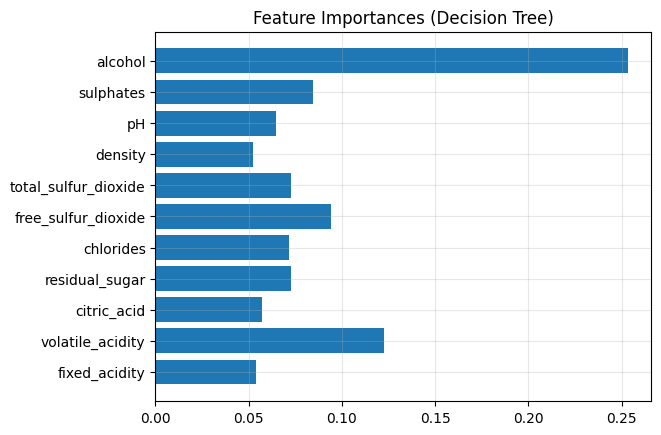

In [18]:
plt.barh(feature_names2,importances_dt)
plt.title("Feature Importances (Decision Tree)")
plt.grid(alpha=0.3)
plt.show()

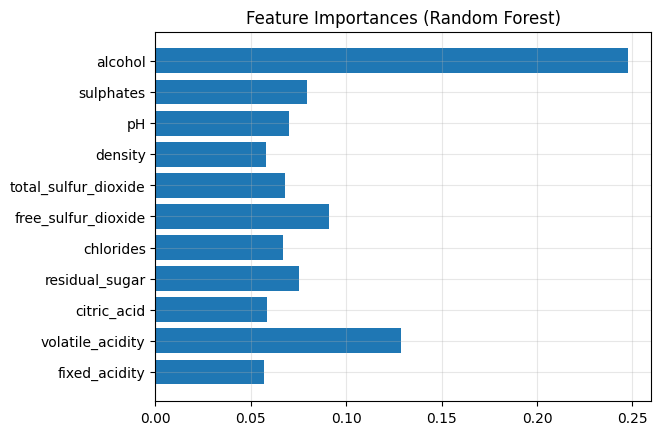

In [19]:
plt.barh(feature_names2,importances_rf)
plt.title("Feature Importances (Random Forest)")
plt.grid(alpha=0.3)
plt.show()